# **Lab experience #3 (STUDENTS): Clustering - basics**

This third lab session aims to explore the importance of **input preparation** (e.g, normalization/scaling) and **feature selection** to obtain a "good" clustering solution. The **effectiveness of the clustering** is also evaluated. This lab session refers to Prof. Stella's lecture no.3 "Introduction to clustering".

In this lab, you are going to **(re-)use already known packages** (matplotlib, scipy, numpy, seaborn, sklearn). Check the two previous lab solutions.
For [**scikit-learn**](https://scikit-learn.org/stable/index.html), used to pre-process data, check documentatio, if needed, [here](https://scikit-learn.org/stable/modules/preprocessing.html#preprocessing)).



Notes:
*   to rapidly access the documentation you can also create a new code cell and type in "function_name?" (e.g., matplotlib?) and run the cell.
*   to execute the code, click on the corresponding cell and press the SHIFT-ENTER keys simultaneously or click on the "play" icon.


**Read the step-by-step instructions below** carefully and write your own code to fill the missing steps. **Guiding slides** are also available on Moodle to better explain the steps to perform.

### Load the input data and import useful packages

Here, you will import the data matrix to work on during this lab, set parameters N and M (defined by the number of objects and attributes, respectively), and import the useful packages.

---



In [63]:
import numpy as np
import os
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import pandas as pd
from sklearn.preprocessing import StandardScaler, Normalizer, MinMaxScaler, RobustScaler


# Load the data matrix (X)

X = np.load("/home/nigus/EDU/Unsupervised/Lab/Lab03/Dataset_lab0.npy")

# Set the number of objects (no. rows of X)
print(X.shape)
N = X.shape[0]


# Set the no. of attributes or features (no. columns of X)
M = X.shape[1]


# ----------------------------------------
# Check the matrix shape and values
# ----------------------------------------
print("The matrix has shape = ", np.shape(X))
print('It has %d objects and %d attributes.' % (N, M) )
# print("Here are all values: \n", X)

(30, 11)
The matrix has shape =  (30, 11)
It has 30 objects and 11 attributes.


In [10]:
print(os.path.exists("/home/nigus/EDU/Unsupervised/Lab/Lab03/Dataset_lab03.npy"))

True


**Task 1:** Randomly select two attributes (i.e., features), and print the data on screen and visualize it in _2 different ways choosing_ image (imshow), line plot (plot), or scatterplot (either sns.scatterplot or plot).

In [26]:
# -----------------------------------------------------------------------------
# TASK 1: Randomly select two features (give feat1 and feat2 a numerical index)
# -----------------------------------------------------------------------------
feat1, feat2 = np.random.choice(X.shape[1], size=2, replace=False)
print(feat1)
print(feat2)
# check
values = X[:,[feat1,feat2]]
print(values.shape)

6
2
(30, 2)


**Task 2:** Reduce the dataset to keep 2 attributes, only, and visualize the objects in a scatterplot with those attributes.



In [27]:
# ---------------------------
# TASK 2a: Reduce the dataset
# ---------------------------
X_red = values
print(X_red)

[[ 5.84 -1.22]
 [30.57 -1.16]
 [32.8  -1.28]
 [26.9  -1.13]
 [31.88 -1.62]
 [24.43 -1.11]
 [23.57 -1.18]
 [ 9.92 -1.43]
 [29.32 -1.16]
 [22.92 -1.95]
 [10.95 -1.05]
 [ 8.98 -1.62]
 [28.57 -1.51]
 [22.28 -1.79]
 [ 9.79 -1.41]
 [29.98 -1.6 ]
 [14.06  0.85]
 [-0.31  0.88]
 [ 0.13  0.76]
 [ 6.18  0.83]
 [ 3.38  0.89]
 [ 1.24  0.66]
 [ 3.57  0.96]
 [14.06  0.55]
 [-0.36  1.03]
 [10.68  0.88]
 [ 5.27  0.62]
 [-2.    0.63]
 [ 5.39  0.96]
 [-0.52  0.92]]


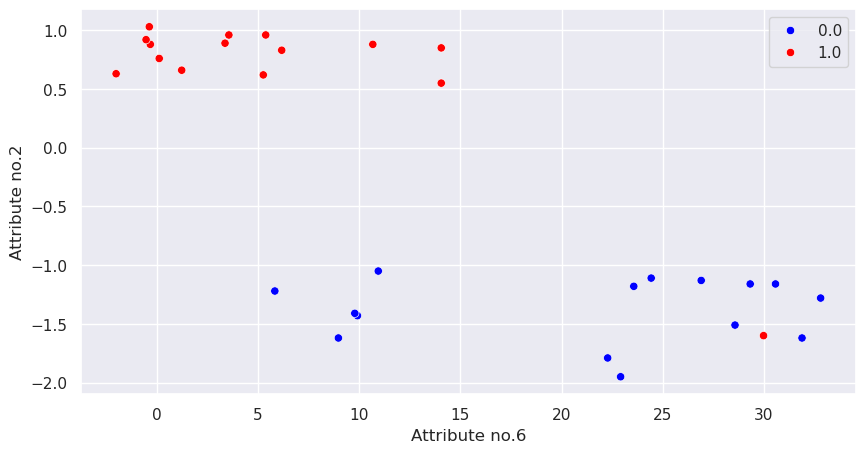

In [28]:
# --------------------
# TASK 2b: Scatterplot
# --------------------
fig1 = plt.figure('Dataset described by two attributes', figsize=(10,5))
PAL = ['blue', 'red']
x = X[:, feat1]
y = X[:, feat2]
sns.scatterplot(x = x, y = y, hue=X[:,-1], palette=PAL)
sns.set_theme(style='dark')
plt.xlabel('Attribute no.%s' % feat1)
plt.ylabel('Attribute no.%s' % feat2)
plt.grid()
plt.show()
# fig1.savefig('Scatterplot_with_random_attributes.png', dpi=100)

**Task 3:** Compute the proximity matrix and plot it.

Hint:
*   check Lab02 solution
*   for the proximity metric, you can choose one of the following: 'euclidean', 'minkowski', 'mahalanobis',  'hamming'/'matching', 'jaccard', 'cosine', 'correlation'.
*   for computing the distances between two objects you can use: pdist() from the [scipy.spatial.distance](https://docs.scipy.org/doc/scipy/reference/spatial.distance.html) package.

**Note that the proximity values depend on the choice of the attributes that you use to represent objects.**

_Note: alternatively, you can use sklearn.metrics.pairwise_distances package (documentation available [here](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise_distances.html) )._

In [42]:
# -------------------------------------
# TASK 3a: Compute the PROXIMITY MATRIX
# -------------------------------------
from scipy.spatial.distance import pdist as pdist
from scipy.spatial.distance import squareform as sf

# Choose one proximity metric
METRIC = "mahalanobis"

# Compute the proximity matrix using pdist() (see Lab02)
PM =  pdist(X, metric = METRIC)
PM = sf(PM).round(2)

In [47]:
# Choose one proximity metric
METRIC2 = "cityblock"

# Compute the proximity matrix using pdist() (see Lab02)
PM2 =  pdist(X, metric = METRIC2)
PM2 = sf(PM2).round(2)

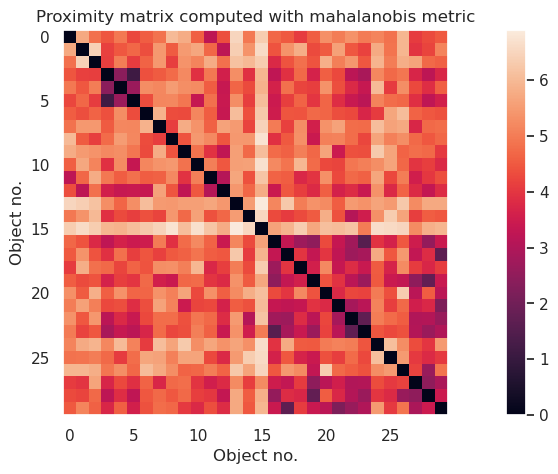

               0       1       2       3       4       5       6       7       8       9      10      11      12      13      14      15      16      17      18      19      20      21      22      23      24      25      26      27      28      29
       0     0.0    5.71    4.82    4.46    4.95    4.24    4.57    4.87    6.01    5.76    4.58    3.21    4.36    6.49    4.93    6.34     4.7    4.51    4.09    4.57    5.31    5.02    5.35    4.99    5.13    4.85    5.93    4.07    4.29    4.52
       1    5.71     0.0    6.41    4.17    4.49    4.69    4.34    5.46    4.54    5.48    5.68    4.69    3.22    6.37    5.37    6.62    4.43    5.36    5.81    4.28    4.53    5.59    4.49    4.18    5.74    4.88    5.93    3.96    4.22    5.12
       2    4.82    6.41     0.0    4.14    5.02     4.1    4.65    5.45    4.12    5.36    5.12    5.76    4.83    6.14    5.98    6.33    3.79    4.44    4.84    4.43    5.83    5.05    5.42    4.49     5.9    5.02    5.79    5.64    4.73    4.62
    

In [48]:
# ------------------------------------------------------
# TASK 3b: Plot the proximity matrix. Hint: use imshow()
# ------------------------------------------------------
fig2 = plt.figure(figsize=(15, 5))
# plot the matrix as image
plt.imshow(PM)
plt.xlabel('Object no.')
plt.ylabel('Object no.')
plt.title('Proximity matrix computed with %s metric' % METRIC)
plt.colorbar()
plt.show()

# Print the proximity matrix values
format_row = "{:>8}" * (len(pd.DataFrame(PM).columns.values) + 1)
print(format_row.format("", *pd.DataFrame(PM).columns.values))
for r, row in zip(pd.DataFrame(PM).columns.values, PM):
    print(format_row.format(r, *row))

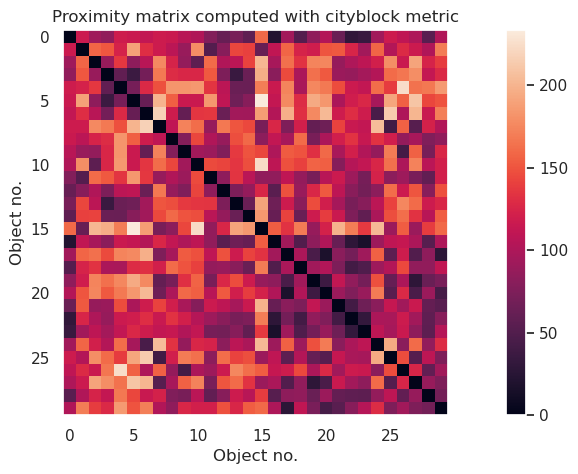

               0       1       2       3       4       5       6       7       8       9      10      11      12      13      14      15      16      17      18      19      20      21      22      23      24      25      26      27      28      29
       0     0.0   117.1   92.38   85.01  118.99  116.31  111.64  117.56  115.91  106.07   101.9   77.34   62.08   71.63   57.91   160.2    22.2   94.18   52.25   84.09  103.83   64.03    30.6   34.77   93.05  118.03  110.06  100.65   54.07  101.77
       1   117.1     0.0   158.0   152.1  123.14  189.22  130.76  117.73  108.29   88.95  178.72   51.14   79.89  143.79  140.65   62.16  110.72  158.08  124.83  119.55  150.45  153.04  125.64   94.01  158.42  103.81  128.88  117.39  101.36  169.65
       2   92.38   158.0     0.0   88.75  136.27   83.33  105.78  176.63  124.09    85.7   56.77  161.27  101.68  108.16  141.43  202.16    97.3  163.91  133.78  173.77   174.2   87.96  100.97   108.7  121.61  178.72  115.96  191.02  123.97  138.87
    

In [49]:
# ------------------------------------------------------
# TASK 3b: Plot the proximity matrix. Hint: use imshow()
# ------------------------------------------------------
fig3 = plt.figure(figsize=(15, 5))
# plot the matrix as image
plt.imshow(PM2)
plt.xlabel('Object no.')
plt.ylabel('Object no.')
plt.title('Proximity matrix computed with %s metric' % METRIC2)
plt.colorbar()
plt.show()

# Print the proximity matrix values
format_row = "{:>8}" * (len(pd.DataFrame(PM2).columns.values) + 1)
print(format_row.format("", *pd.DataFrame(PM2).columns.values))
for r, row in zip(pd.DataFrame(PM2).columns.values, PM2):
    print(format_row.format(r, *row))

**Task 4:** Compute the "centroids", i.e., the mean point of each group of objects, _using only the two selected attributes_ and print their coordinates.

In [94]:
# ----------------------------------------------------------
# TASK4a: Compute the centroids of each clusters (see Lab02)
# ----------------------------------------------------------

DIM = X_red.shape[1]                        # dimensionality of the dataset, i.e., how many attributes to represent each object
centroidk = np.zeros((K, DIM))

print("We need to compute %d centroids, as we have %d clusters.\n" % (K, K) )
for k in range(0, K):
   # compute the cluster_points
   cluster_points = X_red[labels == k]
   print(f"Cluster {k} points:\n", cluster_points.round(2))

   # Compute the coordinates of the centroid of each group
   centroidk[k,:] = np.mean(cluster_points, axis=0)
   print("The centroid of cluster %d has coordinates: " % k, *centroidk[k,:].round(2), "\n")

We need to compute 2 centroids, as we have 2 clusters.

Cluster 0 points:
 [[32.8  -1.28]
 [26.9  -1.13]
 [31.88 -1.62]
 [24.43 -1.11]
 [ 9.92 -1.43]
 [29.32 -1.16]
 [10.95 -1.05]
 [ 8.98 -1.62]
 [28.57 -1.51]
 [22.28 -1.79]
 [ 9.79 -1.41]
 [14.06  0.85]
 [-0.31  0.88]
 [ 3.38  0.89]
 [-0.36  1.03]
 [-2.    0.63]
 [ 5.39  0.96]]
The centroid of cluster 0 has coordinates:  15.06 -0.58 

Cluster 1 points:
 [[ 5.84 -1.22]
 [30.57 -1.16]
 [23.57 -1.18]
 [22.92 -1.95]
 [29.98 -1.6 ]
 [ 0.13  0.76]
 [ 6.18  0.83]
 [ 1.24  0.66]
 [ 3.57  0.96]
 [14.06  0.55]
 [10.68  0.88]
 [ 5.27  0.62]
 [-0.52  0.92]]
The centroid of cluster 1 has coordinates:  11.81 -0.07 



[15.05764706 -0.58058824]
[11.80692308 -0.07153846]


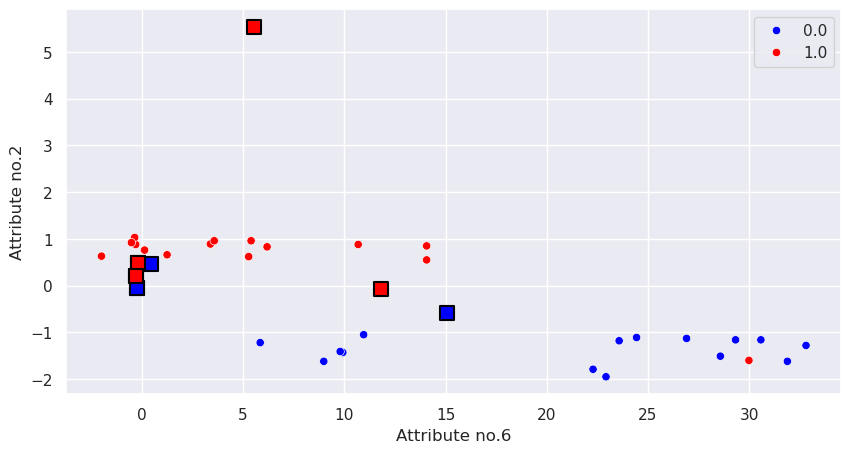

In [95]:
# ------------------------------------------------------------
# TASK4b: Plot the centroids for all groups in the same figure
# ------------------------------------------------------------
plt.figure(fig1)
for k in range(0, K):
    print(centroidk[k,:])
    plt.scatter(x=centroidk[k,0], y=centroidk[k,1], s=100, color=PAL[k], marker='s', edgecolor='black', linewidth=1.5)
plt.show()

**Task 5:** Compute the intra-cluster distance (d) and the inter-cluster distance (D). Print both values.

Use the following definitions:
*   **intra-cluster distance**: average distance between the pairwise distances of all objects in the cluster (i.e., group)
*   **inter-cluster distance**: distance between centroids.

In [96]:
# -------------------------------------------------
# TASK5: Compute intra- and inter-cluster distances
# -------------------------------------------------

# Intra-cluster distances (average over all pairwise distances)
d = np.zeros(K)
for k in range(0,K):
  ind = np.array( np.where(X[:,-1]==k) )
  print(ind.size)
  print(PM[ind][0])
  PM_k = PM[ind][0]
  d[k] = np.mean( PM_k[np.triu_indices(ind.size, k = 1)] )

print("The intra-cluster distance of the two clusters are: ", d.round(2))


# Inter-cluster distance
D = pdist(centroidk, metric=METRIC)
D = sf(D).round(2)

print("The inter-cluster distance of the two clusters is: ", D[0,1].round(2))

15
[[0.   5.71 4.82 4.46 4.95 4.24 4.57 4.87 6.01 5.76 4.58 3.21 4.36 6.49
  4.93 6.34 4.7  4.51 4.09 4.57 5.31 5.02 5.35 4.99 5.13 4.85 5.93 4.07
  4.29 4.52]
 [5.71 0.   6.41 4.17 4.49 4.69 4.34 5.46 4.54 5.48 5.68 4.69 3.22 6.37
  5.37 6.62 4.43 5.36 5.81 4.28 4.53 5.59 4.49 4.18 5.74 4.88 5.93 3.96
  4.22 5.12]
 [4.82 6.41 0.   4.14 5.02 4.1  4.65 5.45 4.12 5.36 5.12 5.76 4.83 6.14
  5.98 6.33 3.79 4.44 4.84 4.43 5.83 5.05 5.42 4.49 5.9  5.02 5.79 5.64
  4.73 4.62]
 [4.46 4.17 4.14 0.   2.41 1.15 4.38 4.53 4.75 5.2  3.91 4.94 3.58 5.3
  3.91 5.93 3.25 3.92 4.71 3.65 4.59 4.27 3.2  2.88 5.17 4.72 4.91 3.69
  3.22 3.73]
 [4.95 4.49 5.02 2.41 0.   2.65 5.26 5.17 5.5  5.28 5.24 4.57 3.37 4.68
  4.29 5.87 3.63 4.82 4.22 4.12 5.35 4.34 3.79 3.38 6.01 4.08 5.29 4.27
  3.87 4.59]
 [4.24 4.69 4.1  1.15 2.65 0.   4.32 5.15 5.19 4.92 3.34 4.84 3.4  5.29
  4.14 6.06 3.47 4.12 4.64 4.01 4.68 3.87 3.4  3.2  5.1  4.79 4.7  3.9
  3.23 3.59]
 [4.57 4.34 4.65 4.38 5.26 4.32 0.   5.88 4.33 4.28 5.15 

ValueError: The number of observations (2) is too small; the covariance matrix is singular. For observations with 2 dimensions, at least 3 observations are required.

**Task 6** Answer the following question in your lab report, adding a short motivation.

**Question:** "Based on inter-/intra-cluster distances, do you think the found one is a good clustering solution?"


---


### **_This is the end of Part 1._**


---



---

**Task 7**: Go back to the original data matrix (with 10 attributes), plot it as a 2D image, and now select two attributes based on some criteria that you decide.

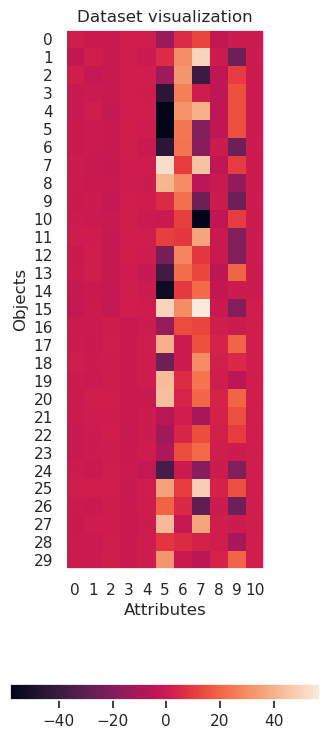

In [97]:
# -----------------------------------------------------
# TASK7a: Visualize the original data matrix as an image
# -----------------------------------------------------
fig3 = plt.figure(figsize=(4,10))
plt.title('Dataset visualization')
# plot the image
plt.imshow(X)
plt.xlabel('Attributes')
plt.ylabel('Objects')
plt.xticks(np.arange(0, M, step=1)) #ALTERNATIVE: plt.xticks(np.arange(M), ['1', '2', '3'])
plt.yticks(np.arange(0, N, step=1))
plt.colorbar(orientation='horizontal')
plt.show()

Selected attributes: 2 and 3
Reduced matrix shape: (30, 2)
The centroid of cluster 0 has coordinates:  -0.58 0.48 

The centroid of cluster 1 has coordinates:  -0.07 0.03 



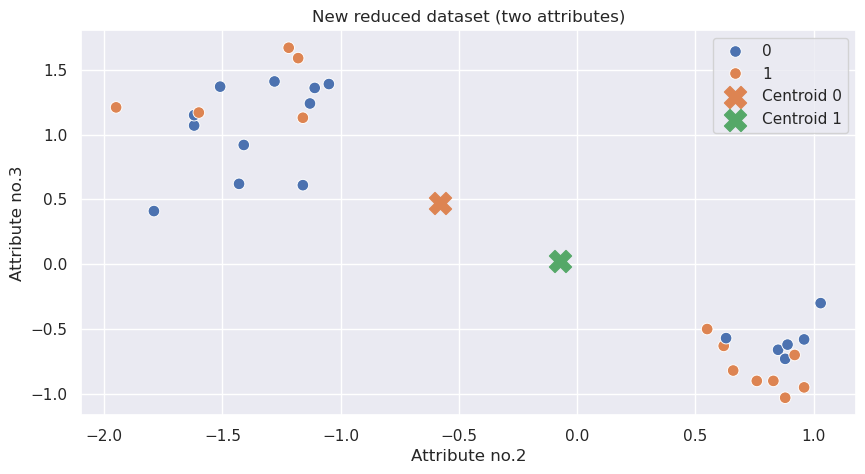

In [98]:
# -----------------------------------------------------------
# TASK7b: Select two attributes and reduce the initial matrix
# -----------------------------------------------------------

# Choose two DIFFERENT attributes
feat3, feat4 = np.random.choice(X.shape[1], size=2, replace=False)

# Reduce the data matrix
X_red2 = X[:, [feat3, feat4]]

print("Selected attributes:", feat3, "and", feat4)
print("Reduced matrix shape:", X_red2.shape)

# Compute the centroids in the reduced 2D space
centroidk_red2 = np.zeros((K, 2))

for k in range(K):
    cluster_points = X_red2[labels == k]

    if len(cluster_points) == 0:
        print(f"Cluster {k} is empty!")
        continue

    centroidk_red2[k, :] = np.mean(cluster_points, axis=0)
    print("The centroid of cluster %d has coordinates: " % k,
          *centroidk_red2[k, :].round(2), "\n")

# Verify your choice by scatterplotting the new reduced dataset
fig4 = plt.figure('New reduced dataset (two attributes)', figsize=(10, 5))
sns.set_theme(style='dark')

# scatter plot of points
sns.scatterplot(
    x=X_red2[:, 0],
    y=X_red2[:, 1],
    hue=labels,
    palette='deep',
    s=70
)

# add centroids
for k in range(K):
    plt.scatter(
        centroidk_red2[k, 0],
        centroidk_red2[k, 1],
        marker='X',
        s=250,
        label=f'Centroid {k}'
    )

plt.xlabel('Attribute no.%s' % feat3)
plt.ylabel('Attribute no.%s' % feat4)
plt.title('New reduced dataset (two attributes)')
plt.grid()
plt.legend()
plt.show()

**Task 8:** Repeat tasks 3 and 5, to support your previous choice (Task 7), and derive conclusions.


---


### **_This is the end of Part 2._**


---



---

Very often, before going to clustering or any other ML-based modelling, _input scaling or normalization_ can be considered. Here, you will explore the effect of the four main transformations (using sklearn) on this specific input dataset:

*   [sklearn.preprocessing.StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)

*   [sklearn.preprocessing.normalize](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.normalize.html)

*   [sklearn.preprocessing.RobustScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.RobustScaler.html)

*   [sklearn.preprocessing.MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html)


**Task 9:** Consider your reduced dataset (X_red2 from Task 7), apply one of the above transformations (call the output as X_red2_transformed), and compute centroids (task 4) to derive conclusions on the effect of such scaling.


_Note: to use them, use .fit_transform() that computes parameters (e.g., mean, std) during the "fit" phase, and then applies the transformation on the data during the "transform" phase._

In [ ]:
# Note: All scalers have been already imported (see the very beginning of this file).
# You can choose among: MinMaxScaler(), RobustScaler(), Normalizer(), StandardScaler()

# Initialize the scaler you want to use
scaler = Normalizer()

# Apply the scaling to data using .fit_transform()
# X_red2_transformed =

In [ ]:
# Compute the new centroids
centroidk_transf = np.zeros((2,DIM))

for k in range(0, K):
   # ind =
   # cluster_points =
   # print(cluster_points.round(2))
   # centroidk_transf[k,:] =
   print("The centroid of cluster %d has coordinates: " % k, *centroidk_transf[k,:].round(2), "\n")

In [ ]:
# Plot the new scatterplot, with centroids, of transformed X_red2 and compare with the previous one
fig5, (ax1, ax2) = plt.subplots(1, 2, figsize= (10,5), gridspec_kw={'width_ratios': [1, 1]})
fig5.suptitle('Explore the effect of scaling')

# panel (a): No scaling
plt.subplot(121)
# plot here the objects of the reduced dataset with proper choice of attributes (X_red2). Use the usual style (colors, marker style for centroids)
sns.set_theme(style='dark')
ax1.set_xlabel('Attribute no.%s' % feat3)
ax1.set_ylabel('Attribute no.%s' % feat4)
ax1.set_title('Raw (reduced) dataset')
ax1.grid()
for k in range(0, K):
    # add the centroids


# panel (b): With scaling
plt.subplot(122)
# plot here the objects of the reduced and transformed dataset with proper choice of attributes (X_red2_transformed)
sns.set_theme(style='dark')
ax2.set_xlabel('Attribute no.%s' % feat3)
ax2.set_ylabel('Attribute no.%s' % feat4)
ax2.set_title('Transformed (reduced) dataset')
ax2.grid()
for k in range(0, K):
    # add centroids
plt.show()

**Task 10a:** Repeat also tasks 3 and 5, to support your claim of Task 9 (scaler choice).

**Task 10b:** Apply another scaler, and derive conclusions on the different effects on the clustering.



---


## **_This is the end of Lab#3 session._**


---



---

